In [2]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt

In [3]:
delivery= pd.read_csv('../../Data_Files/IPL_data/IPL_Ball_by_Ball_2008_2022.csv')
delivery

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225950,335982,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225951,335982,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225952,335982,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore


In [5]:
delivery['ballnumber'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [ ]:
# but we want only 6 balls and only those balls on which six run get
temp_data= delivery[(delivery['ballnumber'].isin([1,2,3,4,5,6])) & (delivery['batsman_run']==6)]
temp_data 

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
16,1312200,1,2,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
22,1312200,1,3,5,YBK Jaiswal,Yash Dayal,JC Buttler,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
103,1312200,1,17,2,TA Boult,R Sai Kishore,R Parag,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
107,1312200,1,17,6,OC McCoy,R Sai Kishore,R Parag,NaN,6,0,6,0,0,NaN,NaN,NaN,Rajasthan Royals
142,1312200,2,3,5,MS Wade,M Prasidh Krishna,Shubman Gill,NaN,6,0,6,0,0,NaN,NaN,NaN,Gujarat Titans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225848,335982,1,19,2,BB McCullum,P Kumar,Mohammad Hafeez,NaN,6,0,6,0,0,NaN,NaN,NaN,Kolkata Knight Riders
225852,335982,1,19,6,BB McCullum,P Kumar,Mohammad Hafeez,NaN,6,0,6,0,0,NaN,NaN,NaN,Kolkata Knight Riders
225882,335982,2,4,4,JH Kallis,AB Agarkar,W Jaffer,NaN,6,0,6,0,0,NaN,NaN,NaN,Royal Challengers Bangalore
225932,335982,2,12,1,P Kumar,LR Shukla,Z Khan,NaN,6,0,6,0,0,NaN,NaN,NaN,Royal Challengers Bangalore


In [15]:
# now create an grid using pivot_table which will include every over ball and aggreagate of six runs on those ball

grid = temp_data.pivot_table(index='overs',columns='ballnumber', values='batsman_run', aggfunc='count')
grid

ballnumber,1,2,3,4,5,6
overs,,,,,,
0,9,17,31,39,33,27
1,31,40,49,56,58,54
2,75,62,70,72,58,76
3,60,74,74,103,74,71
4,71,76,112,80,81,72
5,77,102,63,86,78,80
6,34,56,49,59,64,38
7,59,62,73,70,69,56
8,86,83,79,81,73,52


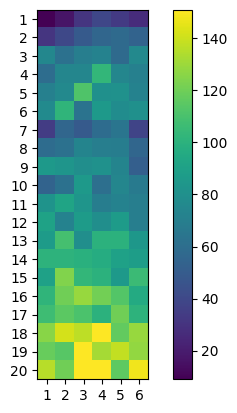

In [ ]:
# use plt.imshow(grid) to dispplay hitmap

plt.Figure(figsize=(20,12))

plt.imshow(grid)

plt.yticks(delivery['overs'].unique(), list(range(1,21)))
plt.xticks(np.arange(0,6), list(range(1,7)))
plt.colorbar() 

In [19]:
grid_df =pd.DataFrame(grid)

grid_df


ballnumber,1,2,3,4,5,6
overs,,,,,,
0,9,17,31,39,33,27
1,31,40,49,56,58,54
2,75,62,70,72,58,76
3,60,74,74,103,74,71
4,71,76,112,80,81,72
5,77,102,63,86,78,80
6,34,56,49,59,64,38
7,59,62,73,70,69,56
8,86,83,79,81,73,52
